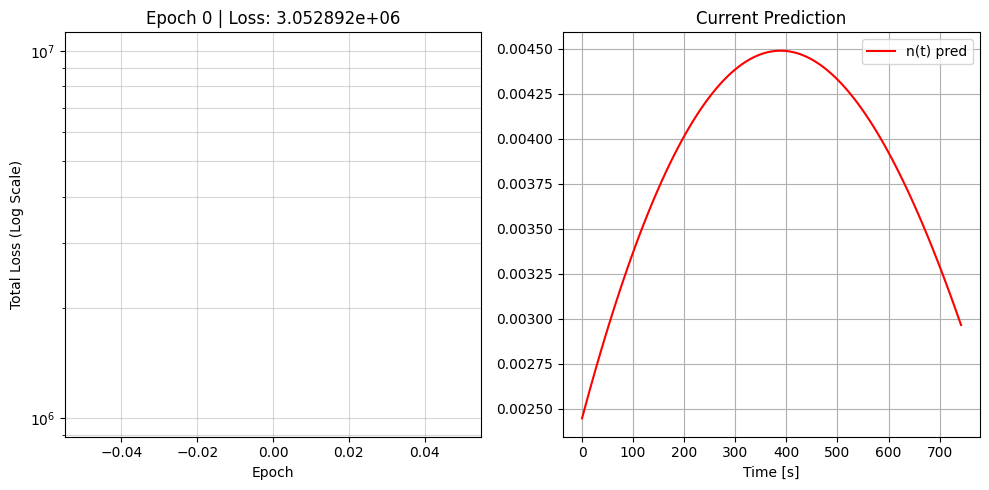

KeyboardInterrupt: 

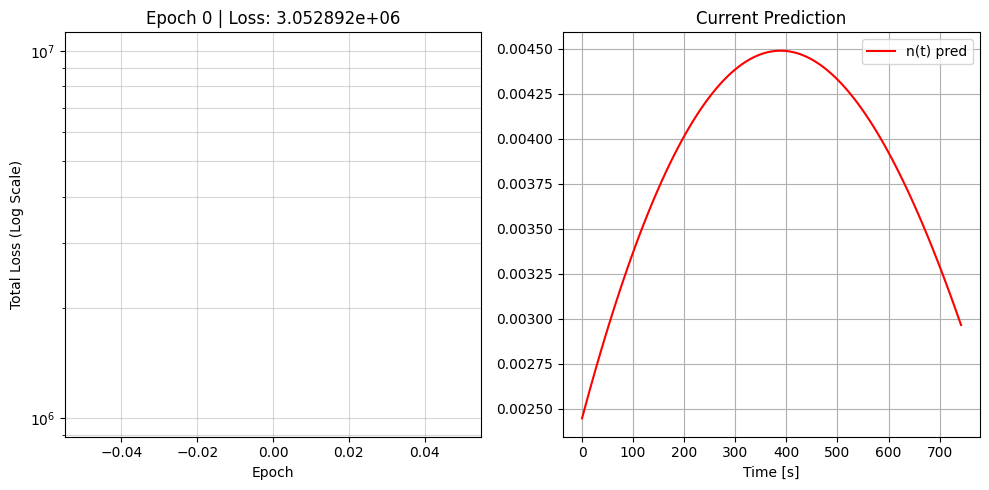

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from IPython import display  # 실시간 그래프 업데이트를 위한 모듈

# 1. 물리적 파라미터 설정 (논문 Table 5 참조)
##### debug 0 #####
Lambda = 1.2e-4  # 평균 중성자 수명 [s]
beta = torch.tensor([0.000213, 0.001413, 0.001264, 0.002548, 0.000742, 0.000271], dtype=torch.float32)
lam = torch.tensor([0.01244, 0.0305, 0.1114, 0.3013, 1.1361, 3.013], dtype=torch.float32)
beta_tot = torch.sum(beta)
T_max = 742.0  # 총 시간 영역

# 초기 조건 (Normalized)
n0 = 1.0
##### debug 1 #####
c0 = (beta / (lam * Lambda)) * n0

# 2. 신경망 구조 정의
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 7)
        )

    def forward(self, t):
        return self.net(t)

# 3. 반응도 함수 (RT-1)
def get_reactivity(t_phys):
    ##### debug 2 #####
    rho_pcm = 500.0 - 20.0 * (t_phys - 0.49) / (1.0 + torch.exp(-20.0 * (t_phys - 0.49)))
    return rho_pcm * 1e-5

# 4. 물리 손실 계산 함수
def compute_loss(model, t_nodes):
    t_nodes.requires_grad = True
    y = model(t_nodes)

    n = y[:, 0:1]
    c = y[:, 1:7]

    dn_dt = torch.autograd.grad(n, t_nodes, torch.ones_like(n), create_graph=True)[0] / T_max

    dc_dt = []
    for i in range(6):
        dci_dt = torch.autograd.grad(c[:, i:i+1], t_nodes, torch.ones_like(c[:, i:i+1]), create_graph=True)[0] / T_max
        dc_dt.append(dci_dt)
    dc_dt = torch.cat(dc_dt, dim=1)

    ##### debug 3 #####
    t_phys = t_nodes * T_max
    rho = get_reactivity(t_phys)

    sum_lam_c = torch.sum(lam * c, dim=1, keepdim=True)
    f_n = dn_dt - ((rho - beta_tot) / Lambda) * n - sum_lam_c
    f_c = dc_dt - (beta / Lambda) * n + lam * c

    loss_physics = torch.mean(f_n**2) + torch.mean(f_c**2)

    t0 = torch.zeros((1, 1), requires_grad=True)
    y0_pred = model(t0)
    loss_ic = torch.mean((y0_pred[0, 0] - n0)**2) + torch.mean((y0_pred[0, 1:] - c0)**2)

    return loss_physics + (loss_ic * 100)

# 5. 모델 학습 루프 및 실시간 시각화
model = PINN()
optimizer = optim.Adam(model.parameters(), lr=0.0003)
t_train = torch.linspace(0, 1, 100).view(-1, 1)

# Loss 기록을 위한 리스트
epoch_history = []
loss_history = []

print("학습 시작...")

plt.figure(figsize=(10, 5))

for epoch in range(100001):
    optimizer.zero_grad()
    loss = compute_loss(model, t_train)
    loss.backward()
    optimizer.step()

    # 데이터 기록
    current_loss = loss.item()

    if epoch % 1000 == 0:
        epoch_history.append(epoch)
        loss_history.append(current_loss)

        # 그래프 실시간 업데이트
        display.clear_output(wait=True)
        plt.clf() # 이전 그래프 지우기

        # 1번 서브플롯: Loss 곡선 (로그 스케일)
        plt.subplot(1, 2, 1)
        plt.plot(epoch_history, loss_history, 'b-')
        plt.yscale('log') # PINN은 Loss 범위가 크므로 로그 스케일 권장
        plt.title(f"Epoch {epoch} | Loss: {current_loss:.6e}")
        plt.xlabel("Epoch")
        plt.ylabel("Total Loss (Log Scale)")
        plt.grid(True, which="both", ls="-", alpha=0.5)

        # 2번 서브플롯: 현재 모델의 예측값 확인 (중간 점검)
        plt.subplot(1, 2, 2)
        model.eval()
        with torch.no_grad():
            t_test = torch.linspace(0, 1, 100).view(-1, 1)
            y_pred = model(t_test)
            plt.plot(t_test.numpy() * T_max, y_pred[:, 0].numpy(), 'r-', label='n(t) pred')
        plt.title("Current Prediction")
        plt.xlabel("Time [s]")
        plt.legend()
        plt.grid(True)
        model.train()

        plt.tight_layout()
        display.display(plt.gcf())

# 최종 결과 시각화
display.clear_output(wait=True)
print("학습 완료.")

# 최종 예측 그래프
model.eval()
with torch.no_grad():
    t_test = torch.linspace(0, 1, 500).view(-1, 1)
    y_pred = model(t_test).numpy()
    t_plot = t_test.numpy() * T_max

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epoch_history, loss_history)
plt.yscale('log')
plt.title("Final Loss History")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t_plot, y_pred[:, 0], label='Predicted Neutron Density (n)', color='red')
plt.title("RT-1 Final Prediction")
plt.xlabel("Time [s]")
plt.ylabel("Normalized Density")
plt.legend()
plt.grid(True)
plt.show()

학습 시작...
epoch      0 | loss 2.1844e+02
epoch   1000 | loss 2.8875e+00
epoch   2000 | loss 6.9051e-01
epoch   3000 | loss 2.1558e-01
epoch   4000 | loss 1.0303e-01
epoch   5000 | loss 1.8977e-01
epoch   6000 | loss 3.4182e-02
epoch   7000 | loss 2.1968e-02
epoch   8000 | loss 3.5464e-02
epoch   9000 | loss 8.9287e-03
epoch  10000 | loss 6.5713e-03
epoch  11000 | loss 3.2790e-01
epoch  12000 | loss 3.9963e-03
epoch  13000 | loss 3.2446e-03
epoch  14000 | loss 2.7274e-03
epoch  15000 | loss 3.4612e-03
epoch  16000 | loss 2.0361e-03
epoch  17000 | loss 1.8497e-03
epoch  18000 | loss 9.7028e-03
epoch  19000 | loss 1.9361e-03
epoch  20000 | loss 1.3331e-03
epoch  21000 | loss 1.2091e-03
epoch  22000 | loss 3.3623e-03
epoch  23000 | loss 9.9433e-04
epoch  24000 | loss 9.0679e-04
epoch  25000 | loss 2.7959e-02
epoch  26000 | loss 1.3256e-02
epoch  27000 | loss 9.5150e-04
epoch  28000 | loss 3.6205e-03
epoch  29000 | loss 2.8785e-02
epoch  30000 | loss 5.9246e-04
epoch  31000 | loss 5.4928e-04

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/pinn_rt1_v2.png'

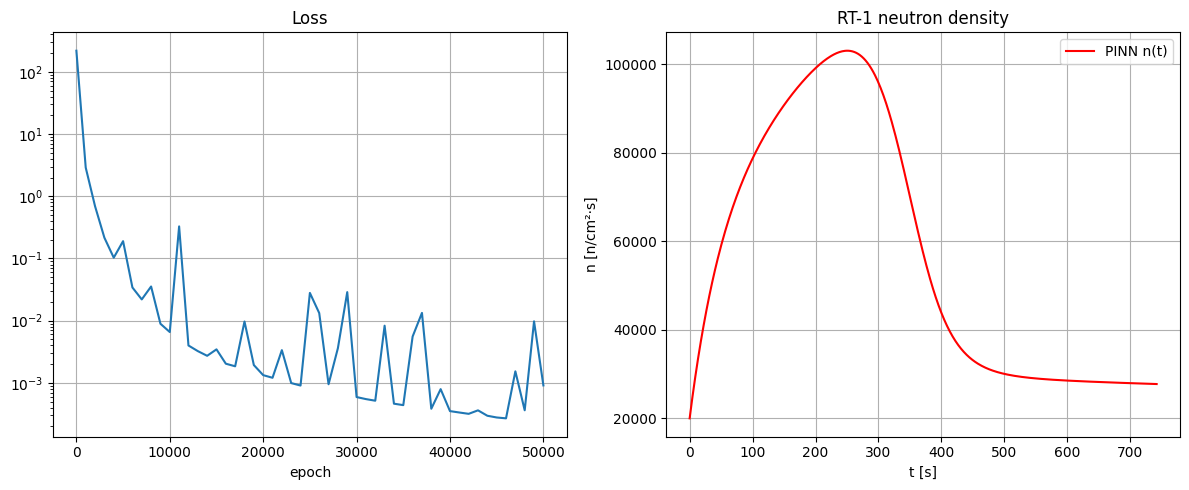

In [ ]:
# -*- coding: utf-8 -*-
"""
PINN for PKEs — RT-1 (논문 Table 4)
핵심 수정 (이전 코드 대비):
  논문은 정규화 시간 τ ∈ [0,1] 을 '그대로' 시간 변수로 취급해 PKE 를 푼다.
  즉 T_max 곱셈을 하지 않는다.  ("ρ를 2 orders of magnitude 크게 스케일"
  이라는 본문 문장이 이 의미.)  결과만 t = τ·T_max 로 다시 표시.
무차원화는 이전과 동일 — c_tilde_i = c_i / c0_raw_i.
"""
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt

# ---- 물리 파라미터 (Table 5) ----
Lambda  = 1.2e-4
beta    = torch.tensor([0.000213, 0.001413, 0.001264, 0.002548, 0.000742, 0.000271])
lam     = torch.tensor([0.01244, 0.0305, 0.1114, 0.3013, 1.1361, 3.013])
beta_tot = beta.sum()
T_max   = 742.0

n0      = 1.0
c0_set  = 1.0 # c_set = c/c0_raw
c0_raw  = beta / (lam * Lambda) * n0          # ~142 ~ 7100
lam_c0  = lam * c0_raw                         # = beta/Lambda  (n식 sum 항 계수)

# ---- 신경망 ----
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1,32), nn.Tanh(),
            nn.Linear(32,32), nn.Tanh(),
            nn.Linear(32,32), nn.Tanh(),
            nn.Linear(32,32), nn.Tanh(),
            nn.Linear(32,7))
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, t): return self.net(t)

# ---- 반응도 ρ(τ) — 정규화 시간을 그대로 입력 (Table 4 RT-1) ----
def get_reactivity(tau):
    rho_pcm = 500.0 * torch.sigmoid(-20.0*(tau - 0.49))
    return rho_pcm * 1e-5

# ---- 손실 (T_max 인자 없음!) ----
def compute_loss(model, tau):
    tau = tau.clone().requires_grad_(True)
    y = model(tau)
    n  = y[:, 0:1]
    c  = y[:, 1:7]                              # tilde c

    dn = torch.autograd.grad(n, tau, torch.ones_like(n), create_graph=True)[0]
    dc_list = [torch.autograd.grad(c[:, i:i+1], tau,
                                   torch.ones_like(c[:, i:i+1]),
                                   create_graph=True)[0] for i in range(6)]
    dc = torch.cat(dc_list, dim=1)

    rho = get_reactivity(tau)
    rhs_n = ((rho - beta_tot)/Lambda) * n + torch.sum(lam_c0 * c, dim=1, keepdim=True)
    f_n   = dn - rhs_n                          # ← T_max 곱하지 않음
    f_c   = dc - lam*(n - c)                    # ← 동일

    loss_phys = torch.mean(f_n**2) + torch.mean(f_c**2)

    t0 = torch.zeros((1,1))
    y0 = model(t0)
    loss_ic = (y0[0,0] - n0)**2 + torch.mean((y0[0,1:] - c0_set)**2)

    return loss_phys + 100.0*loss_ic

# ---- 학습 ----
torch.manual_seed(0)
model = PINN()
opt   = optim.Adam(model.parameters(), lr=1e-3)
sch   = optim.lr_scheduler.StepLR(opt, step_size=20000, gamma=0.5)

tau_train = torch.linspace(0, 1, 100).view(-1, 1)
hist_e, hist_l = [], []

print("학습 시작...")
for ep in range(50001):
    opt.zero_grad()
    loss = compute_loss(model, tau_train)
    loss.backward()
    opt.step()
    sch.step()
    if ep % 1000 == 0:
        hist_e.append(ep); hist_l.append(loss.item())
        print(f"epoch {ep:6d} | loss {loss.item():.4e}")
print("완료.")

# ---- 시각화 ----
SCALE_N = 0.2e5
model.eval()
with torch.no_grad():
    tau_t = torch.linspace(0,1,500).view(-1,1)
    y     = model(tau_t).numpy()
    t_phys= tau_t.numpy()*T_max

fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].plot(hist_e, hist_l); ax[0].set_yscale('log')
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].grid(True)

ax[1].plot(t_phys, y[:,0]*SCALE_N, 'r-', label='PINN n(t)')
ax[1].set_title("RT-1 neutron density")
ax[1].set_xlabel("t [s]"); ax[1].set_ylabel("n [n/cm²·s]")
ax[1].legend(); ax[1].grid(True)
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/pinn_rt1_v2.png", dpi=120)
plt.show()